In [1]:
import os 
os.chdir('../../')

In [2]:
print('done')

done


In [3]:
from backbones.stable_diffusion import StableDiffusion

# 사용 예
model = StableDiffusion(model_id="runwayml/stable-diffusion-v1-5")
print(model)

/home/scpark/miniconda3/envs/sana/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-11-26 17:34:28.040100: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-26 17:34:28.069328: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/scpark/miniconda3/envs/sana/lib/python3.10/site-packages/google/protobuf/runtime_v

In [4]:
model.unet_enc_out

[]

In [5]:
import matplotlib.pyplot as plt

def show_compare(euler_img, dpm_img, unipc_img):
    fig, axes = plt.subplots(1, 3, figsize=(18, 10))
    axes[0].imshow(euler_img); axes[0].axis('off'); axes[0].set_title('Euler')
    axes[1].imshow(dpm_img);  axes[1].axis('off'); axes[1].set_title('DPM-Solver')
    axes[2].imshow(unipc_img);  axes[2].axis('off'); axes[2].set_title('UniPC')
    plt.tight_layout()
    plt.show()


torch.Size([1, 4, 64, 64])


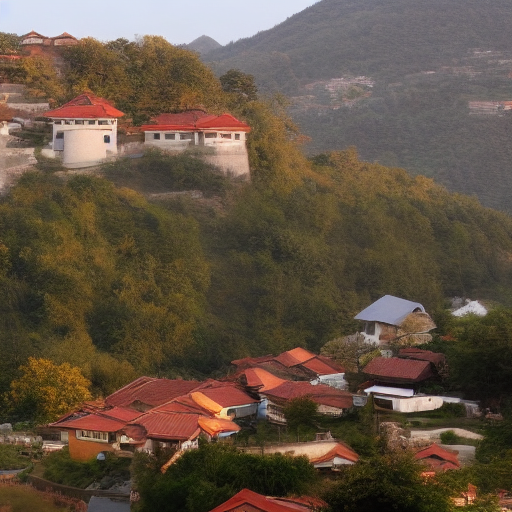

In [6]:
from solvers.others.euler_solver import Euler_Solver

pos_texts = ["A serene twilight view of a traditional Korean hanok village nestled between misty mountain slopes: "]
neg_texts = ["lowres, bad anatomy, deformed, blurry, pixelated, oversaturated, underexposed, overexposed, artifact, "]

noise_schedule = model.get_noise_schedule()
model_fn = model.get_model_fn(noise_schedule=noise_schedule, pos_conds=pos_texts, neg_conds=neg_texts, guidance_scale=2.5)
latents = model.get_noise(seeds=[0])
print(latents.shape)

NFE = 15
model.register_hook()
solver = Euler_Solver(noise_schedule, steps=NFE, skip_type='time_uniform', algorithm_type="data_prediction")

euler_latents = solver.sample(latents, model_fn)['samples']
euler_samples = model.decode_vae(euler_latents, pil_output=True)
euler_samples['pil_output'][0]


In [7]:
print(len(model.unet_enc_out))
print(model.unet_enc_out[0].shape)
model.register_hook()

15
torch.Size([2, 1280, 8, 8])


torch.Size([1, 4, 64, 64])


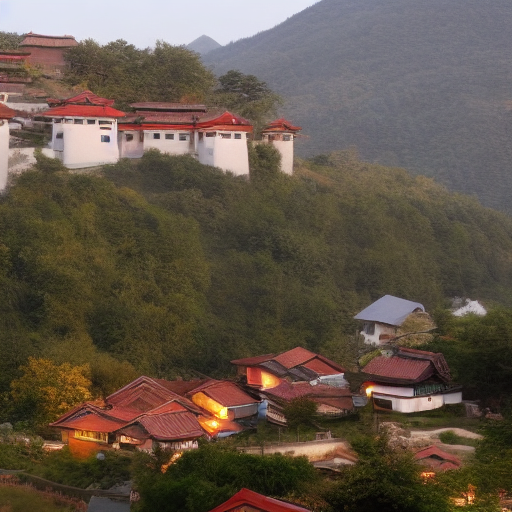

In [8]:
from solvers.others.euler_solver import Euler_Solver

pos_texts = ["A serene twilight view of a traditional Korean hanok village nestled between misty mountain slopes: "]
neg_texts = ["lowres, bad anatomy, deformed, blurry, pixelated, oversaturated, underexposed, overexposed, artifact, "]

noise_schedule = model.get_noise_schedule()
model_fn = model.get_model_fn(noise_schedule=noise_schedule, pos_conds=pos_texts, neg_conds=neg_texts, guidance_scale=3.5)
latents = model.get_noise(seeds=[0])
print(latents.shape)

NFE = 15
solver = Euler_Solver(noise_schedule, steps=NFE, skip_type='time_uniform', algorithm_type="data_prediction")
euler_latents = solver.sample(latents, model_fn)['samples']
euler_samples = model.decode_vae(euler_latents, pil_output=True)
euler_samples['pil_output'][0]


torch.Size([1, 4, 64, 64])


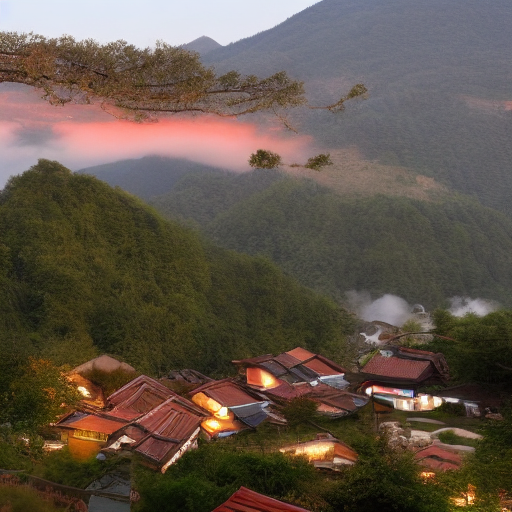

In [9]:
from solvers.others.euler_solver import Euler_Solver

pos_texts = ["A serene twilight view of a traditional Korean hanok village nestled between misty mountain slopes: "]
neg_texts = ["lowres, bad anatomy, deformed, blurry, pixelated, oversaturated, underexposed, overexposed, artifact, "]

noise_schedule = model.get_noise_schedule()
model_fn = model.get_model_fn(noise_schedule=noise_schedule, pos_conds=pos_texts, neg_conds=neg_texts, guidance_scale=4.0)
latents = model.get_noise(seeds=[0])
print(latents.shape)

NFE = 15
solver = Euler_Solver(noise_schedule, steps=NFE, skip_type='time_uniform', algorithm_type="data_prediction")
euler_latents = solver.sample(latents, model_fn)['samples']
euler_samples = model.decode_vae(euler_latents, pil_output=True)
euler_samples['pil_output'][0]


torch.Size([1, 4, 64, 64])


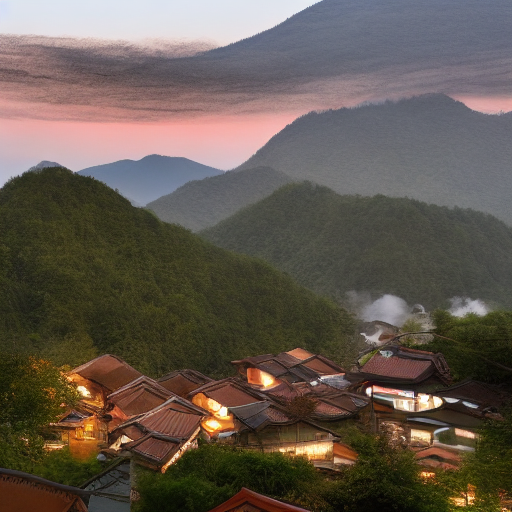

In [10]:
from solvers.others.euler_solver import Euler_Solver

pos_texts = ["A serene twilight view of a traditional Korean hanok village nestled between misty mountain slopes: "]
neg_texts = ["lowres, bad anatomy, deformed, blurry, pixelated, oversaturated, underexposed, overexposed, artifact, "]

noise_schedule = model.get_noise_schedule()
model_fn = model.get_model_fn(noise_schedule=noise_schedule, pos_conds=pos_texts, neg_conds=neg_texts, guidance_scale=4.5)
latents = model.get_noise(seeds=[0])
print(latents.shape)

NFE = 15
solver = Euler_Solver(noise_schedule, steps=NFE, skip_type='time_uniform', algorithm_type="data_prediction")
euler_latents = solver.sample(latents, model_fn)['samples']
euler_samples = model.decode_vae(euler_latents, pil_output=True)
euler_samples['pil_output'][0]
